In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

## Load and Visualize the data

In [29]:
train_path = '../data/processed/train.npz'
test_path = '../data/processed/test.npz'

def load_data(npz_path):
    data = np.load(npz_path)
    signals = data['stft_windows']
    labels = data['labels']

    return signals, labels

signals, labels = load_data(train_path)

In [31]:
arousals = signals[labels == 1]
non_arousals = signals[labels == 0]

print("Arousal Events: ", arousals.shape)
print("Non Arousal Events: ", non_arousals.shape)

Arousal Events:  (26741, 2, 80, 53)
Non Arousal Events:  (53406, 2, 80, 53)


## View STFT Features 

In [37]:
idx = 0

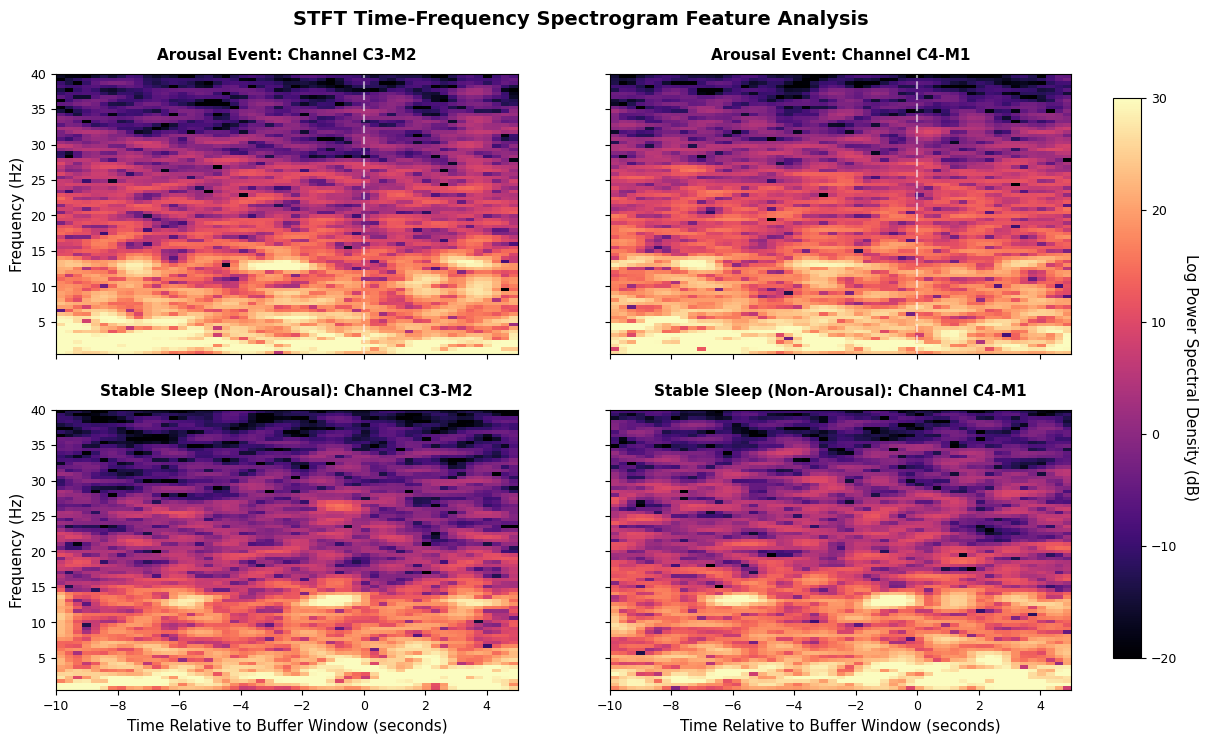

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
extent = [-10, 5, 0.5, 40] 
im_opts = dict(cmap='magma', aspect='auto', origin='lower', extent=extent, vmin=-20, vmax=30)

# Arousal Event Example
axes[0, 0].imshow(arousals[idx][0], **im_opts)
axes[0, 0].set_title('Arousal Event: Channel C3-M2', weight='semibold', pad=10)

im_arousal_ch2 = axes[0, 1].imshow(arousals[idx][1], **im_opts)
axes[0, 1].set_title('Arousal Event: Channel C4-M1', weight='semibold', pad=10)

# Non-Arousal Event Example
axes[1, 0].imshow(non_arousals[idx][0], **im_opts)
axes[1, 0].set_title('Stable Sleep (Non-Arousal): Channel C3-M2', weight='semibold', pad=10)

axes[1, 1].imshow(non_arousals[idx][1], **im_opts)
axes[1, 1].set_title('Stable Sleep (Non-Arousal): Channel C4-M1', weight='semibold', pad=10)

# Add labels to the exterior edge plots only (cleaner grid look)
for ax in axes[1, :]:
    ax.set_xlabel('Time Relative to Buffer Window (seconds)')
for ax in axes[:, 0]:
    ax.set_ylabel('Frequency (Hz)')

# Add vertical marker pinpointing where the onset transitions (at 0 seconds)
for ax in axes[0, :]:
    ax.axvline(x=0, color='white', linestyle='--', alpha=0.6, linewidth=1.5, label='Arousal Target Line')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(im_arousal_ch2, cax=cbar_ax)
cbar.set_label('Log Power Spectral Density (dB)', rotation=270, labelpad=15)

fig.suptitle('STFT Time-Frequency Spectrogram Feature Analysis', 
             fontsize=14, weight='bold', y=0.96)

plt.subplots_layout = dict(wspace=0.15, hspace=0.25)
plt.show()

idx += 1

## TSNE representation

[*] Extracting and flattening features for Electrode 0 (C3-M2 (Left Hemisphere))...
[*] Computing t-SNE embedding for Electrode 0...
[*] Extracting and flattening features for Electrode 1 (C4-M1 (Right Hemisphere))...
[*] Computing t-SNE embedding for Electrode 1...


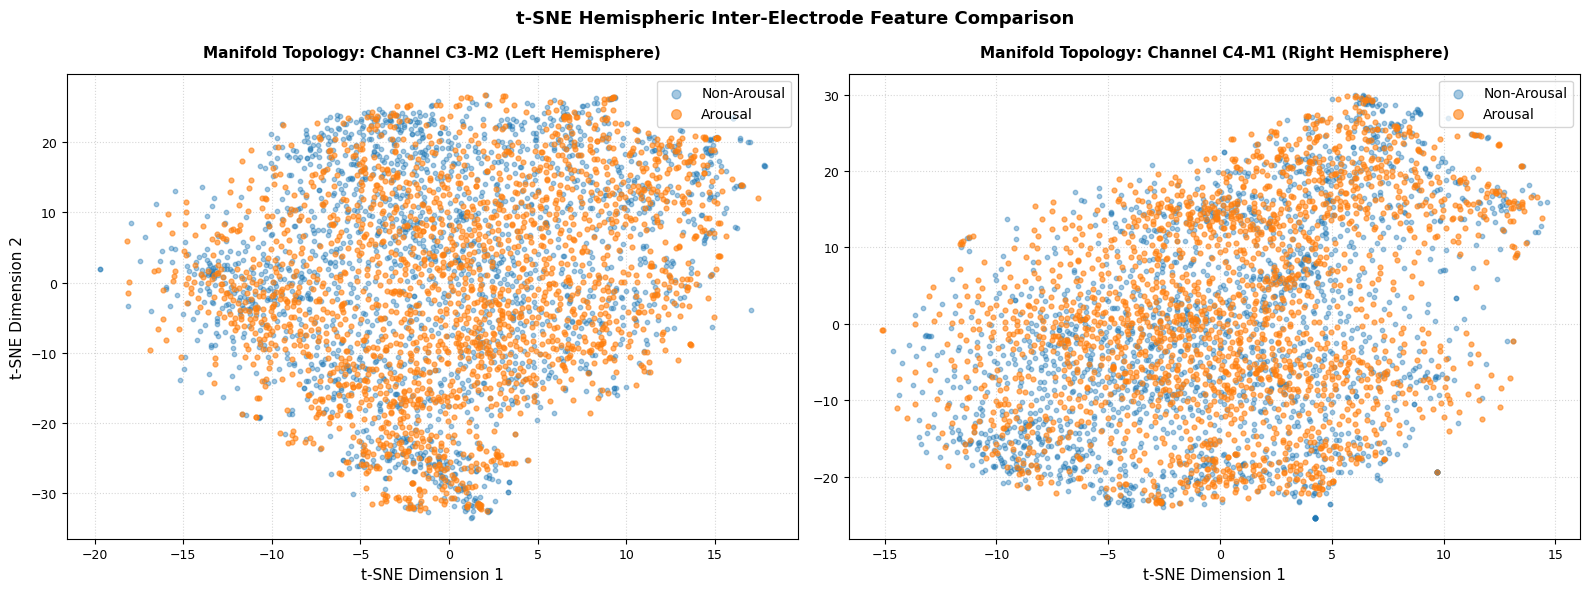

In [62]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

n_samples_per_class = 2000

idx_arousal = np.random.choice(len(arousals), n_samples_per_class, replace=False)
idx_non = np.random.choice(len(non_arousals), n_samples_per_class, replace=False)

# Shape of subsets: (2000, 2, 80, 53)
sub_arousal = arousals[idx_arousal]
sub_non = non_arousals[idx_non]

# Combine into features and labels
X_combined = np.vstack([sub_arousal, sub_non]) # Shape: (4000, 2, 80, 53)
y = np.hstack([np.ones(n_samples_per_class), np.zeros(n_samples_per_class)])

# --- 2. Compute t-SNE Per Electrode ---
electrodes = ["C3-M2 (Left Hemisphere)", "C4-M1 (Right Hemisphere)"]

# Setup side-by-side subplots elegantly
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ch in [0, 1]:
    print(f"[*] Extracting and flattening features for Electrode {ch} ({electrodes[ch]})...")
    
    # Isolate the specific channel and flatten the 2D STFT grid (80x53) to 1D (4240,)
    # Input: (4000, 2, 80, 53) -> Slice channel: (4000, 80, 53) -> Flatten: (4000, 4240)
    X_ch = X_combined[:, ch, :, :].reshape(X_combined.shape[0], -1)
    
    # Scale features (Essential for t-SNE distance metrics)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_ch)
    
    print(f"[*] Computing t-SNE embedding for Electrode {ch}...")
    tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1, init='pca')
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Separate the projections for custom visualization styling
    tsne_arousal = X_tsne[y == 1]
    tsne_non = X_tsne[y == 0]
    
    # Plot on the corresponding subplot axis
    ax = axes[ch]
    ax.scatter(tsne_non[:, 0], tsne_non[:, 1], color='tab:blue', alpha=0.4, s=10, label='Non-Arousal')
    ax.scatter(tsne_arousal[:, 0], tsne_arousal[:, 1], color='tab:orange', alpha=0.6, s=12, label='Arousal')
    
    ax.set_title(f'Manifold Topology: Channel {electrodes[ch]}', weight='semibold', pad=12)
    ax.set_xlabel('t-SNE Dimension 1')
    if ch == 0:
        ax.set_ylabel('t-SNE Dimension 2')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', markerscale=2)

fig.suptitle('t-SNE Hemispheric Inter-Electrode Feature Comparison', fontsize=13, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig('stft_inter_electrode_tsne.png', dpi=300)
plt.show()